# Regression Models

## Goals

In this Assignmnet :

 - You Will impliment the regression models

## Tools
In this lab we will make use of:
- NumPy, a popular library for scientific computing
- Matplotlib, a popular library for plotting data
- Pandas,  a Python library for data analysis

### Import Libraries

![Libraries](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Libraries.png?raw=true)


In [2]:
#Your code Here
#import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

###  Fetch Data From CSV Files

![Load Data](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Load%20N%20show.png?raw=true)

In [4]:
#Your code Here
#Read the trainig and testing data from the file
trainData = pd.read_csv("trainRegression.csv")
testData = pd.read_csv("testRegression.csv")
TrD = trainData.head()

### Show Data

In [5]:
#Your code Here
#Show the first 5 rows of the training data
TrD

,X,R
0,0.01,-0.2730
1,0.02,-0.1170
2,0.03,-0.3090
3,0.04,0.0306
4,0.05,-0.0802


##### Expected Output


![Output 1](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/O1.png?raw=true)


### Type Casting of Data

![TypeCasting](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Type%20Casting.png?raw=true)


In [6]:
#Your code Here
#TypeCast the data into numpy array

x_test = np.array(testData['X'])
y_test = np.array(testData['R'])
x_train = np.array(trainData['X'])
y_train = np.array(trainData['R'])

### Plot Data

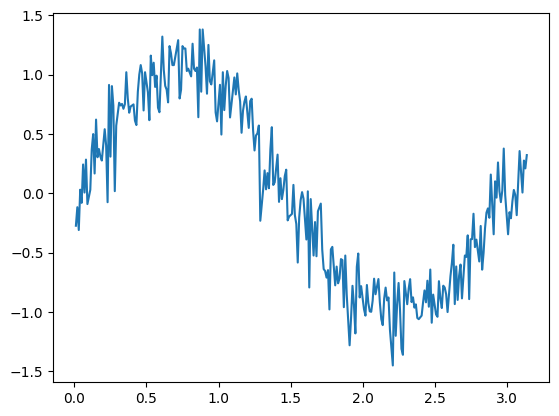

In [7]:
#Your code Here
#Plot your Training Data using matplotlib

plt.plot(x_train, y_train)

plt.show()

##### Expected Output


![Model Equations](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/O2.png?raw=true)


 ### Fit Linear Regression Model (Training data)

 As our linear Model was

![Cost Funtion](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cost%20funtion1.png?raw=true
)

And using derivatives we transformed our model into 2 simultaneous equations

![Model Equations](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Linear%20Model%20Eqs.png?raw=true)


Then converted it in matrix form

![Model Equations](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Linear%20Model.png?raw=true)



NOTE :  Now you are required to compute values wihtout using foor loop on tarining data
- HINT : Use numpy library for this purpose

In [8]:
#Your code Here
#For loop is not recommended in these cases,
#use numpy functions to calculate the values of above variables in one line of code.
#Such as x.shape for number of rows, sum() for sum of all elements in x
#np.dot() or multiply suntion for square of x

m = trainData.shape[0]
matrixA = np.array([
    [m,np.sum(x_train)],
    [np.sum(x_train),np.sum(x_train**2)]
])

matrixB = np.array([
    [np.sum(y_train)],
    [np.sum(x_train*y_train)]
])

print(f"Matrix A: \n\n {matrixA}\n")
print(f"Matrix B: \n\n {matrixB}\n")

Matrix A: 

 [[283.     444.95  ]
 [444.95   932.7465]]

Matrix B: 

 [[   1.39087  ]
 [-126.6414295]]



Expected output

![Linear Model MAtrixes](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Matrixs%20Linear.png?raw=true)


#### Compute Valus of Both Θ`s


In [9]:
#Your code Here
#Calculate the values of 0_node and 0_1 using Matrix Multiplication
#Hint: Use X = A^-1 * B to calculate the values of 0_node and 0_1

theta_0, theta_1 = np.dot(np.linalg.inv(matrixA), matrixB)

matrixX = np.array([theta_0,theta_1])

print(f"Matrix for the linear model: \n\n {matrixX}")

Matrix for the linear model: 

 [[ 0.8736061 ]
 [-0.55251074]]


Expected Output

![Linear Model MAtrixes](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Matrixs%20LinearT.png?raw=true)


### Run Predictions (Testing data)

In [10]:
# Your code Here
# In order to calculate the pridicted values of y
# Use the formula y = 0_node + 0_1 * x
# _____DO NOT USE FOR LOOP_____
# instead Convert the column of test_x into numpy a 2 dimensional matrix
# then use matrix multiplication to calculate the predicted values of y

x_test_matrix = np.column_stack((np.ones(x_test.shape[0]),x_test))
y_pred = np.dot(x_test_matrix,matrixX)

print(f"X_test_matrix shape: {x_test_matrix.shape}")
print(f"Predicted y (first 5): \n{y_pred[:5]}")

X_test_matrix shape: (32, 2)
Predicted y (first 5): 
[[0.8736061 ]
 [0.81835502]
 [0.76310395]
 [0.70785287]
 [0.6526018 ]]


### Mean Square Error

![Cost Funtion](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cost%20funtion1.png?raw=true
)

In [12]:
#Your code Here
#Using cost function calculate the cost of the model

m_test = x_test.shape[0]

error = y_pred.flatten() - y_test
cost = np.sum(error**2) / m_test

print(f"Mean Square Error (Cost): {cost}")

Mean Square Error (Cost): 0.3159321720459774


Expected Output

![MSE of Linear](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/MSE%20Linear.png?raw=true
)

### Plot Data (Train and Test Data)

In [16]:
x_train_matrix = np.column_stack((np.ones(x_train.shape[0]), x_train))
y_train_pred = np.dot(x_train_matrix, matrixX)

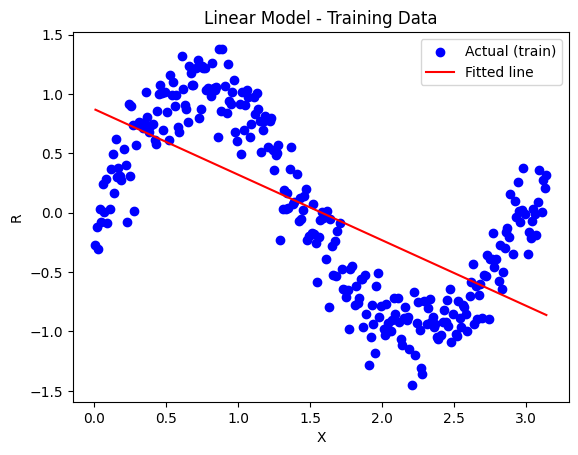

In [17]:
##Your code Here
#Plot the predicted values of y against the test_x

plt.scatter(x_train, y_train, color='blue', label='Actual (train)')
plt.plot(x_train, y_train_pred, color='red', label='Fitted line')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Linear Model - Training Data')
plt.legend()
plt.show()

### Expected Outputs for Linear Model

![Training Data Plot](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Linear%20O.png?raw=true)

![Test Data Plot](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Linear%20O%20test.png?raw=true)


## Now Fit The Quadratic Model

 As our Quadratic Model was

![Cost Funtion for quadratic ](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cost%20funtion2.png?raw=true
)

And using derivatives we transformed our model into 3 simultaneous equations

![Model Equations of quadratic](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Quad%20Model%20Eqs.png?raw=true)


Then converted it in matrix form

![Model Formula of Quadratic](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Quad%20Model1.png?raw=true)



NOTE :  Now you are required to compute values wihtout using foor loop on tarining data
- HINT : Use numpy library for this purpose

In [19]:
#Your code Here
#For loop is not recommended in these cases,
#use numpy functions to calculate the values of above variables in one line of code.
#Such as x.shape for number of rows, sum() for sum of all elements in x
#np.dot() or multiply suntion for square of x

m = trainData.shape[0]          # you already have this pattern from cell-16

Sx  = np.sum(x_train)
Sx2 = np.sum(x_train**2)
Sx3 = np.sum(x_train**3)
Sx4 = np.sum(x_train**4)

Sy   = np.sum(y_train)
Sxy  = np.sum(x_train * y_train)
Sx2y = np.sum((x_train**2) * y_train)

matrixA = np.array([
    [m,   Sx,  Sx2],
    [Sx,  Sx2, Sx3],
    [Sx2, Sx3, Sx4]
])

matrixB = np.array([
    [Sy],
    [Sxy],
    [Sx2y]
])

print(f"Matrix A: \n\n {matrixA}\n")
print(f"Matrix B: \n\n {matrixB}\n")

Matrix A: 

 [[ 283.          444.95        932.7465    ]
 [ 444.95        932.7465     2199.781025  ]
 [ 932.7465     2199.781025   5533.85257677]]

Matrix B: 

 [[   1.39087   ]
 [-126.6414295 ]
 [-378.87568955]]



Expected Output

![Quadratic Model Matrixes](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Matrixs%20Quad1.png?raw=true)

#### Compute Valus Of Three Θ`s


In [22]:
#Your code Here
#Calculate the values of 0_node and 0_1 using Matrix Multiplication
#Hint: Use X = A^-1 * B to calculate the values of 0_node , 0_1 and 0_2

theta_0, theta_1, theta_2 = np.dot(np.linalg.inv(matrixA), matrixB)

matrixX = np.array([theta_0,theta_1,theta_2])

print(f"Matrix X for the quadratic model: \n\n {matrixX}")

Matrix X for the quadratic model: 

 [[ 1.10611454]
 [-0.99606599]
 [ 0.14104585]]


Expected Output

![Quadratic Model MAtrixes](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Matrixs%20Quad.png?raw=true)


### Run Predictions (Testing data)

In [23]:
# Your code Here
# In order to calculate the pridicted values of y
# Use the formula y = 0_node + 0_1 * x
# _____DO NOT USE FOR LOOP_____
# instead Convert the column of test_x into numpy a 2 dimensional matrix
# then use matrix multiplication to calculate the predicted values of y

x_test_matrix_quad = np.column_stack((np.ones(x_test.shape[0]), x_test, x_test**2))
y_pred_quad = np.dot(x_test_matrix_quad, matrixX)

print(f"x_test_matrix_quad shape: {x_test_matrix_quad.shape}")
print(f"Predicted y (first 5): \n{y_pred_quad[:5]}")

x_test_matrix_quad shape: (32, 3)
Predicted y (first 5): 
[[1.10611454]
 [1.0079184 ]
 [0.91254317]
 [0.81998887]
 [0.73025548]]


### Mean Square Error

![Cost Funtion](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cost%20funtion2.png?raw=true
)

In [24]:
#Your code Here
#Using cost function calculate the cost of the model

m_test = x_test.shape[0]

error_quad = y_pred_quad.flatten() - y_test
cost_quad = np.sum(error_quad**2) / m_test

print(f"Mean Square Error (Cost) - Quadratic: {cost_quad}")

Mean Square Error (Cost) - Quadratic: 0.32604179594962857


Expected Output

![MSE of Quadratic](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/MSE%20Quad.png?raw=true
)

### Plot Data (Train and Test Data)

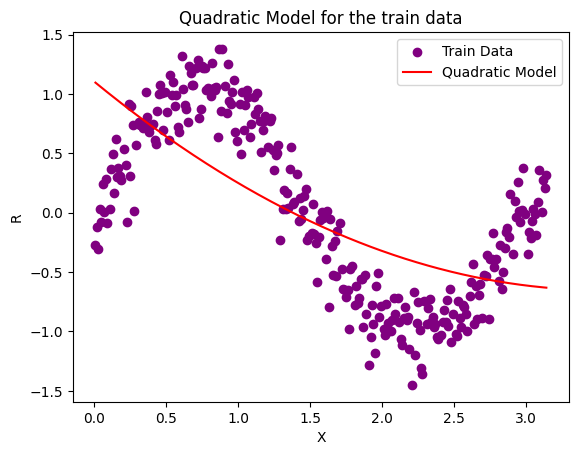

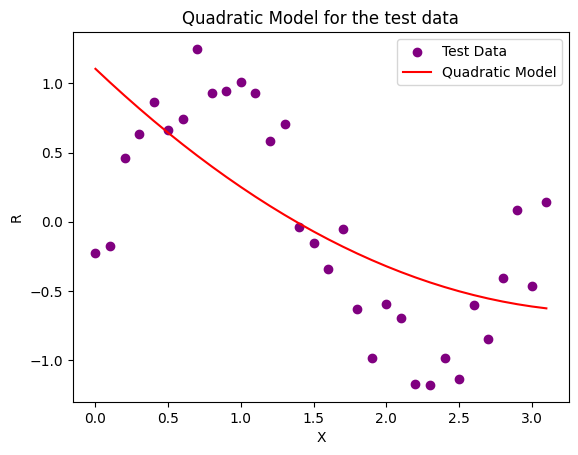

In [25]:
##Your code Here
#Plot the predicted values of y against the test_x

x_train_matrix_quad = np.column_stack((np.ones(x_train.shape[0]), x_train, x_train**2))
y_train_pred_quad = np.dot(x_train_matrix_quad, matrixX)

sort_idx_train = np.argsort(x_train)
sort_idx_test = np.argsort(x_test)

# Plot 1: Training data
plt.figure()
plt.scatter(x_train, y_train, color='purple', label='Train Data')
plt.plot(x_train[sort_idx_train], y_train_pred_quad.flatten()[sort_idx_train], color='red', label='Quadratic Model')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Quadratic Model for the train data')
plt.legend()
plt.show()

# Plot 2: Test data
plt.figure()
plt.scatter(x_test, y_test, color='purple', label='Test Data')
plt.plot(x_test[sort_idx_test], y_pred_quad.flatten()[sort_idx_test], color='red', label='Quadratic Model')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Quadratic Model for the test data')
plt.legend()
plt.show()


### Expected Outputs for Quadratic Model

![Training Data Plot](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Quad%20O.png?raw=true)

![Test Data Plot](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Quad%20O%20tets.png?raw=true)


## Now Fit The Cubic Model

Cubic Model in matrix form

![Model Formula of Quadratic](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cubic%20Model.png?raw=true)



NOTE :  Now you are required to compute values wihtout using foor loop on tarining data
- HINT : Use numpy library for this purpose

In [26]:
#Your code Here
#For loop is not recommended in these cases,
#use numpy functions to calculate the values of above variables in one line of code.
#Such as x.shape for number of rows, sum() for sum of all elements in x
#np.dot() or multiply suntion for square of x

m = trainData.shape[0]

Sx  = np.sum(x_train)
Sx2 = np.sum(x_train**2)
Sx3 = np.sum(x_train**3)
Sx4 = np.sum(x_train**4)
Sx5 = np.sum(x_train**5)
Sx6 = np.sum(x_train**6)

Sy   = np.sum(y_train)
Sxy  = np.sum(x_train * y_train)
Sx2y = np.sum((x_train**2) * y_train)
Sx3y = np.sum((x_train**3) * y_train)

matrixA = np.array([
    [m,   Sx,  Sx2, Sx3],
    [Sx,  Sx2, Sx3, Sx4],
    [Sx2, Sx3, Sx4, Sx5],
    [Sx3, Sx4, Sx5, Sx6]
])

matrixB = np.array([
    [Sy],
    [Sxy],
    [Sx2y],
    [Sx3y]
])

print(f"Matrix A: \n\n {matrixA}\n")
print(f"Matrix B: \n\n {matrixB}\n")

Matrix A: 

 [[  283.           444.95         932.7465      2199.781025  ]
 [  444.95         932.7465      2199.781025    5533.85257677]
 [  932.7465      2199.781025    5533.85257677 14501.33829628]
 [ 2199.781025    5533.85257677 14501.33829628 39086.48841058]]

Matrix B: 

 [[   1.39087   ]
 [-126.6414295 ]
 [-378.87568955]
 [-952.32410353]]



Expected Output

![Cubic Model Matrixes](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Matrixs%20Cubic1.png?raw=true)

#### Compute Valus Of Four Θ`s


In [27]:
#Your code Here
#Calculate the values of 0_node and 0_1 using Matrix Multiplication
#Hint: Use X = A^-1 * B to calculate the values of 0_node , 0_1 ,0_2 and 0_3

theta_0, theta_1, theta_2, theta_3 = np.dot(np.linalg.inv(matrixA), matrixB)

matrixX = np.array([theta_0, theta_1, theta_2, theta_3])

print(f"Matrix X for the cubic model: \n\n {matrixX}")

Matrix X for the cubic model: 

 [[-0.18862637]
 [ 3.94071895]
 [-3.78251095]
 [ 0.83166145]]


Expected Output

![Cubic Model MAtrixes](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Matrixs%20Cubic.png?raw=true)


### Run Predictions (Testing data)

In [28]:
# Your code Here
# In order to calculate the pridicted values of y
# Use the formula y = 0_node + 0_1 * x
# _____DO NOT USE FOR LOOP_____
# instead Convert the column of test_x into numpy a 2 dimensional matrix
# then use matrix multiplication to calculate the predicted values of y

x_test_matrix_cubic = np.column_stack((np.ones(x_test.shape[0]), x_test, x_test**2, x_test**3))
y_pred_cubic = np.dot(x_test_matrix_cubic, matrixX)

print(f"x_test_matrix_cubic shape: {x_test_matrix_cubic.shape}")
print(f"Predicted y (first 5): \n{y_pred_cubic[:5]}")

x_test_matrix_cubic shape: (32, 4)
Predicted y (first 5): 
[[-0.18862637]
 [ 0.16845208]
 [ 0.45487027]
 [ 0.67561819]
 [ 0.83568579]]


### Mean Square Error

In [29]:
#Your code Here
#Using cost function calculate the cost of the model

m_test = x_test.shape[0]

error_cubic = y_pred_cubic.flatten() - y_test
cost_cubic = np.sum(error_cubic**2) / m_test

print(f"Mean Square Error (Cost) - Cubic: {cost_cubic}")

Mean Square Error (Cost) - Cubic: 0.051542057690955614


Expected Output

![MSE of Cubic](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/MSE%20Cubic.png?raw=true
)

### Plot Data (Train and Test Data)

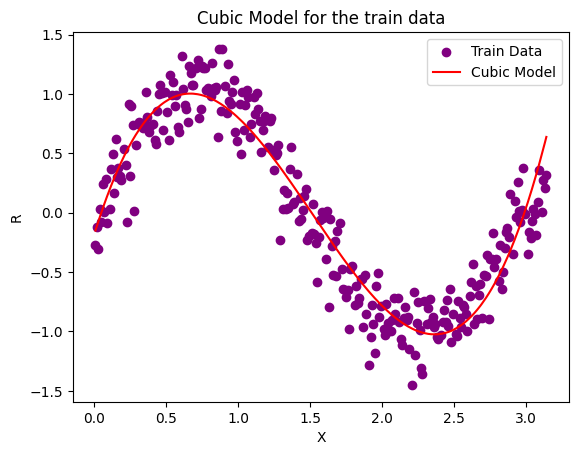

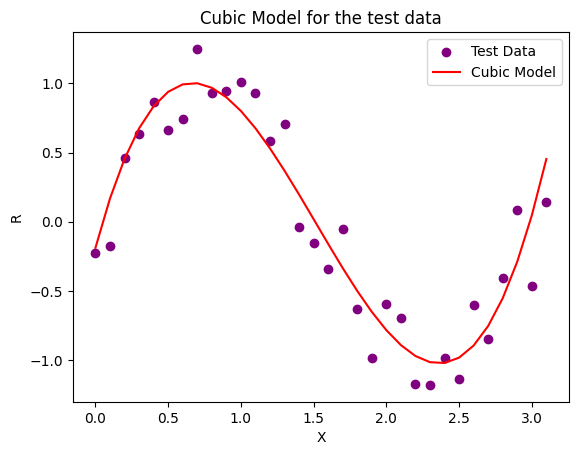

In [30]:
##Your code Here
#Plot the predicted values of y against the test_x

x_train_matrix_cubic = np.column_stack((np.ones(x_train.shape[0]), x_train, x_train**2, x_train**3))
y_train_pred_cubic = np.dot(x_train_matrix_cubic, matrixX)

sort_idx_train = np.argsort(x_train)
sort_idx_test = np.argsort(x_test)

# Plot 1: Training data
plt.figure()
plt.scatter(x_train, y_train, color='purple', label='Train Data')
plt.plot(x_train[sort_idx_train], y_train_pred_cubic.flatten()[sort_idx_train], color='red', label='Cubic Model')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Cubic Model for the train data')
plt.legend()
plt.show()

# Plot 2: Test data
plt.figure()
plt.scatter(x_test, y_test, color='purple', label='Test Data')
plt.plot(x_test[sort_idx_test], y_pred_cubic.flatten()[sort_idx_test], color='red', label='Cubic Model')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Cubic Model for the test data')
plt.legend()
plt.show()


### Expected Outputs for Cubic Model

![Training Data Plot](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cubic%20O.png?raw=true)

![Test Data Plot](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cubic%20O%20test.png?raw=true)


### Now You Are Required To Fit Your 4 , 5 and 6 degree Models Step By Step As You Did Before

## Now Fit The 4 degree Model

Matrix X for the degree 4 model: 

 [[-0.40789474]
 [ 5.3320982 ]
 [-5.77179206]
 [ 1.81519401]
 [-0.15632916]]
Mean Square Error (Cost) - Degree 4: 0.05002521841632793


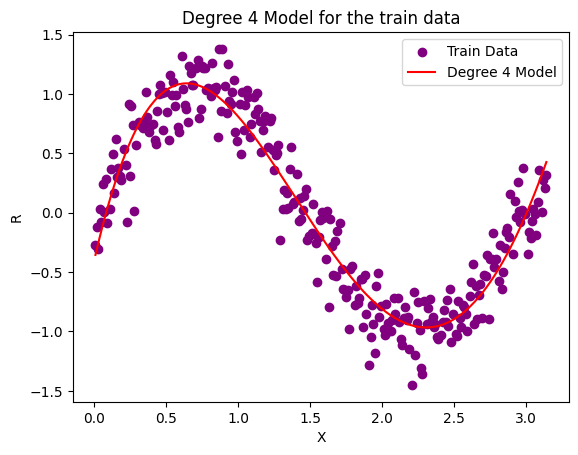

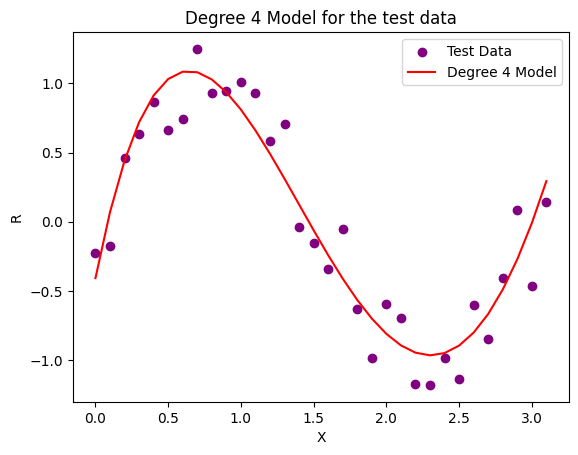

In [31]:
#Your code Here

# Design matrices: each column is a power of x -> [1, x, x^2, x^3, x^4]
x_train_matrix_deg4 = np.column_stack((np.ones(x_train.shape[0]), x_train, x_train**2, x_train**3, x_train**4))
x_test_matrix_deg4 = np.column_stack((np.ones(x_test.shape[0]), x_test, x_test**2, x_test**3, x_test**4))

# Normal equation: theta = (X^T X)^-1 X^T y  (same math as matrixA/matrixB, via matrix multiply instead of named sums)
matrixA_deg4 = np.dot(x_train_matrix_deg4.T, x_train_matrix_deg4)
matrixB_deg4 = np.dot(x_train_matrix_deg4.T, y_train.reshape(-1, 1))
matrixX_deg4 = np.dot(np.linalg.inv(matrixA_deg4), matrixB_deg4)

print(f"Matrix X for the degree 4 model: \n\n {matrixX_deg4}")

# Predictions
y_train_pred_deg4 = np.dot(x_train_matrix_deg4, matrixX_deg4)
y_pred_deg4 = np.dot(x_test_matrix_deg4, matrixX_deg4)

# Mean Square Error
m_test = x_test.shape[0]
error_deg4 = y_pred_deg4.flatten() - y_test
cost_deg4 = np.sum(error_deg4**2) / m_test
print(f"Mean Square Error (Cost) - Degree 4: {cost_deg4}")

# Plots
sort_idx_train = np.argsort(x_train)
sort_idx_test = np.argsort(x_test)

plt.figure()
plt.scatter(x_train, y_train, color='purple', label='Train Data')
plt.plot(x_train[sort_idx_train], y_train_pred_deg4.flatten()[sort_idx_train], color='red', label='Degree 4 Model')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Degree 4 Model for the train data')
plt.legend()
plt.show()

plt.figure()
plt.scatter(x_test, y_test, color='purple', label='Test Data')
plt.plot(x_test[sort_idx_test], y_pred_deg4.flatten()[sort_idx_test], color='red', label='Degree 4 Model')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Degree 4 Model for the test data')
plt.legend()
plt.show()

## Now Fit The 5 degree Model

Matrix X for the degree 5 model: 

 [[-0.15135453]
 [ 2.89713972]
 [-0.36242336]
 [-2.76674175]
 [ 1.48161173]
 [-0.20822932]]
Mean Square Error (Cost) - Degree 5: 0.044206774274051536


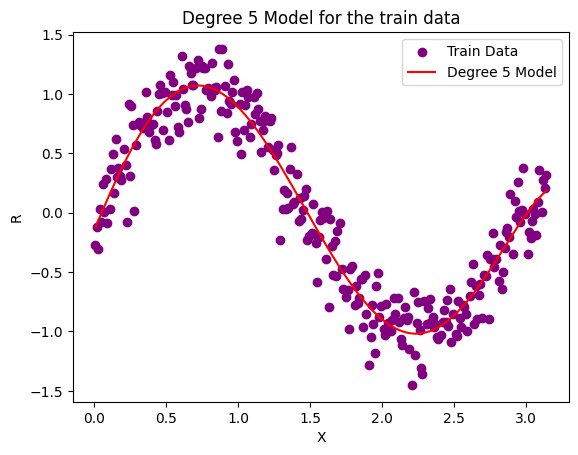

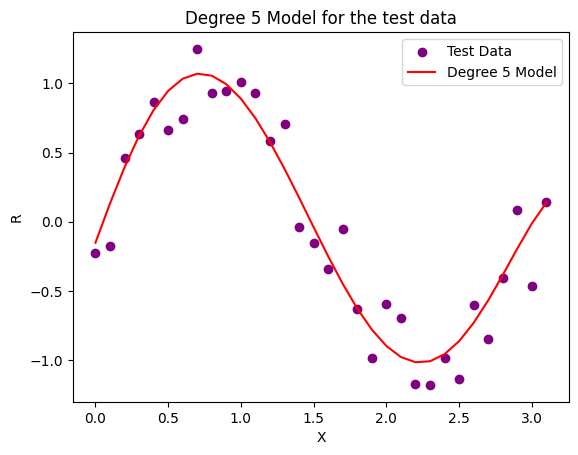

In [32]:
#Your code Here
x_train_matrix_deg5 = np.column_stack((np.ones(x_train.shape[0]), x_train, x_train**2, x_train**3, x_train**4, x_train**5))
x_test_matrix_deg5 = np.column_stack((np.ones(x_test.shape[0]), x_test, x_test**2, x_test**3, x_test**4, x_test**5))

matrixA_deg5 = np.dot(x_train_matrix_deg5.T, x_train_matrix_deg5)
matrixB_deg5 = np.dot(x_train_matrix_deg5.T, y_train.reshape(-1, 1))
matrixX_deg5 = np.dot(np.linalg.inv(matrixA_deg5), matrixB_deg5)

print(f"Matrix X for the degree 5 model: \n\n {matrixX_deg5}")

y_train_pred_deg5 = np.dot(x_train_matrix_deg5, matrixX_deg5)
y_pred_deg5 = np.dot(x_test_matrix_deg5, matrixX_deg5)

m_test = x_test.shape[0]
error_deg5 = y_pred_deg5.flatten() - y_test
cost_deg5 = np.sum(error_deg5**2) / m_test
print(f"Mean Square Error (Cost) - Degree 5: {cost_deg5}")

sort_idx_train = np.argsort(x_train)
sort_idx_test = np.argsort(x_test)

plt.figure()
plt.scatter(x_train, y_train, color='purple', label='Train Data')
plt.plot(x_train[sort_idx_train], y_train_pred_deg5.flatten()[sort_idx_train], color='red', label='Degree 5 Model')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Degree 5 Model for the train data')
plt.legend()
plt.show()

plt.figure()
plt.scatter(x_test, y_test, color='purple', label='Test Data')
plt.plot(x_test[sort_idx_test], y_pred_deg5.flatten()[sort_idx_test], color='red', label='Degree 5 Model')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Degree 5 Model for the test data')
plt.legend()
plt.show()

## Now Fit The 6 degree Model

Matrix X for the degree 6 model: 

 [[-0.12883598]
 [ 2.59932802]
 [ 0.5809851 ]
 [-3.96416676]
 [ 2.19455082]
 [-0.40752775]
 [ 0.02110818]]
Mean Square Error (Cost) - Degree 6: 0.04450867575099107


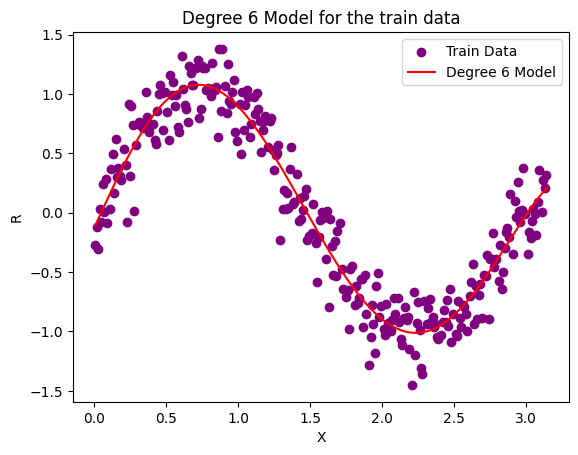

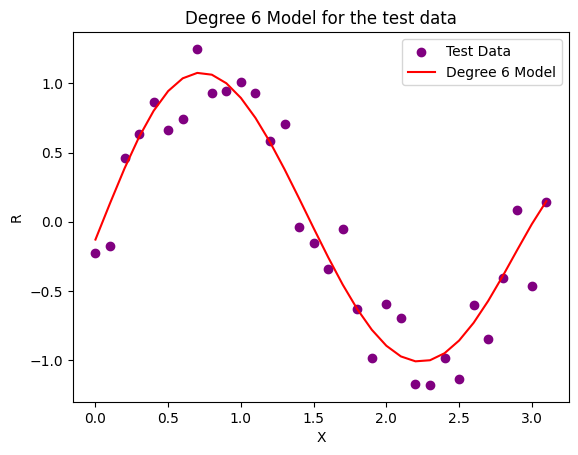

In [33]:
#Your code Here
x_train_matrix_deg6 = np.column_stack((np.ones(x_train.shape[0]), x_train, x_train**2, x_train**3, x_train**4, x_train**5, x_train**6))
x_test_matrix_deg6 = np.column_stack((np.ones(x_test.shape[0]), x_test, x_test**2, x_test**3, x_test**4, x_test**5, x_test**6))

matrixA_deg6 = np.dot(x_train_matrix_deg6.T, x_train_matrix_deg6)
matrixB_deg6 = np.dot(x_train_matrix_deg6.T, y_train.reshape(-1, 1))
matrixX_deg6 = np.dot(np.linalg.inv(matrixA_deg6), matrixB_deg6)

print(f"Matrix X for the degree 6 model: \n\n {matrixX_deg6}")

y_train_pred_deg6 = np.dot(x_train_matrix_deg6, matrixX_deg6)
y_pred_deg6 = np.dot(x_test_matrix_deg6, matrixX_deg6)

m_test = x_test.shape[0]
error_deg6 = y_pred_deg6.flatten() - y_test
cost_deg6 = np.sum(error_deg6**2) / m_test
print(f"Mean Square Error (Cost) - Degree 6: {cost_deg6}")

sort_idx_train = np.argsort(x_train)
sort_idx_test = np.argsort(x_test)

plt.figure()
plt.scatter(x_train, y_train, color='purple', label='Train Data')
plt.plot(x_train[sort_idx_train], y_train_pred_deg6.flatten()[sort_idx_train], color='red', label='Degree 6 Model')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Degree 6 Model for the train data')
plt.legend()
plt.show()

plt.figure()
plt.scatter(x_test, y_test, color='purple', label='Test Data')
plt.plot(x_test[sort_idx_test], y_pred_deg6.flatten()[sort_idx_test], color='red', label='Degree 6 Model')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Degree 6 Model for the test data')
plt.legend()
plt.show()

### Comment on the results by comparing all of your models

The linear and quadratic models don't do a good job — their error stays high on both train and test data, so they're too simple to capture the actual pattern in the data.

Things change a lot at degree 3 — the error drops sharply, which means the data really does follow a curve closer to a cubic shape.

Degrees 4 and 5 keep improving a bit more, so those extra terms are still helping.

At degree 6, the training error basically stops improving, and the test error goes up slightly instead of down. That's a sign the model is starting to overfit — it's fitting tiny noise in the training data instead of the real pattern, which hurts it on new data.

Overall, degree 5 gives the best result since it has the lowest test error. Degree 6 doesn't help further, and degrees 1-2 are just too basic for this data.